In [36]:
from scipy.optimize import minimize
import numpy as np
from typing import List
from matplotlib import pyplot as plt
import optuna

NUM_DEGREES = 4

In [37]:
def to_hsl(matrix: np.ndarray, rgb: np.ndarray) -> np.ndarray:
    assert rgb.shape == (3,)
    assert matrix.shape == (3,3)
    ycbcr = matrix @ rgb.T

    hsl = np.zeros(3)
    hsl[2] = ycbcr[0]
    hsl[0] = np.arctan2(ycbcr[2], ycbcr[1])
    hsl[1] = np.sqrt(ycbcr[1]**2 + ycbcr[2]**2)
    return hsl

def to_rgb(matrix: np.ndarray, hsl: np.ndarray) -> np.ndarray:
    assert hsl.shape == (3,)
    assert matrix.shape == (3,3)
    ycbcr = np.zeros(3)
    ycbcr[0] = hsl[2]
    ycbcr[1] = hsl[1] * np.cos(hsl[0])
    ycbcr[2] = hsl[1] * np.sin(hsl[0])
    rgb = np.linalg.inv(matrix) @ ycbcr
    return rgb


def get_rgb_to_ycbcr_mat(lum_coeffs: np.ndarray) -> np.ndarray:
    dest = np.zeros((3, 3))
    dest[0][0] = lum_coeffs[0]
    dest[0][1] = lum_coeffs[1]
    dest[0][2] = lum_coeffs[2]
    dest[1][0] = -0.5 * (lum_coeffs[0] / (1.0 - lum_coeffs[2]))
    dest[1][1] = -0.5 * (lum_coeffs[1] / (1.0 - lum_coeffs[2]))
    dest[1][2] = 0.5
    dest[2][0] = 0.5
    dest[2][1] = -0.5 * (lum_coeffs[1] / (1.0 - lum_coeffs[0]))
    dest[2][2] = -0.5 * (lum_coeffs[2] / (1.0 - lum_coeffs[0]))
    return dest

def get_matrix(degrees: List[float]) -> np.ndarray:
    assert len(degrees) == NUM_DEGREES
    matrix = get_rgb_to_ycbcr_mat(np.array([0.21, 0.7, 0.09]))
    inv_matrix = np.linalg.inv(matrix)
    axis1 = inv_matrix[:, 1]
    axis2 = inv_matrix[:, 2]

    axes = np.array([axis1, axis2])

    assert axes.shape == (2, 3)
    scaling = np.array([
        [degrees[0], degrees[1]],
        [degrees[2], degrees[3]],
    ])
    assert scaling.shape == (2, 2)
    new_axes = scaling @ axes
    inv_matrix[:, 1] = new_axes[0]
    inv_matrix[:, 2] = new_axes[1]
    matrix = np.linalg.inv(inv_matrix)
    return matrix


def get_full_matrix(degrees: List[float]) -> np.ndarray:
    assert len(degrees) == 6
    matrix = get_rgb_to_ycbcr_mat(np.array([0.21, 0.7, 0.09]))
    matrix[1][0] = degrees[0]
    matrix[1][1] = degrees[1]
    matrix[1][2] = degrees[2]
    matrix[2][0] = degrees[3]
    matrix[2][1] = degrees[4]
    matrix[2][2] = degrees[5]
    return matrix


def forward(degrees: List[float], rgb: np.ndarray, known_rotation: float) -> np.ndarray:
    assert rgb.shape == (3,)
    assert np.array(degrees).shape == (NUM_DEGREES,)
    matrix = get_matrix(degrees)
    hsl = to_hsl(matrix, rgb)
    hsl[0] += known_rotation
    new_rgb = to_rgb(matrix, hsl)
    return new_rgb

def forward_bulk(degrees: List[float], rgb: np.ndarray, known_rotation: float) -> np.ndarray:
    n, c = rgb.shape
    rgb_out = np.zeros_like(rgb)
    for i in range(n):
        rgb_out[i] = forward(degrees, rgb[i], known_rotation)
    return rgb_out

def loss(degrees: List[float], rgb_in: np.ndarray, rgb_out: np.ndarray, known_rotation: float) -> float:
    n, c = rgb_in.shape

    assert c == 3
    assert rgb_out.shape == rgb_in.shape

    # Error coefficients
    rgb_pred = forward_bulk(degrees, rgb_in, known_rotation)
    l = np.sum((rgb_out - rgb_pred) ** 2) / n

    # scaling shit
    red = np.array([1.0, 0.0, 0.0])
    hsl = to_hsl(get_matrix(degrees), red)

    l += hsl[0]**2 # red should be at zero.
    l += (hsl[1] - 1.0)**2

    return l

def regression_matrix(rgb_in: np.ndarray, rgb_out: np.ndarray, known_rotation: float) -> np.ndarray:
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective(trial):
        init_degrees = np.array([
            trial.suggest_float(f"d{i}", -2.0, 2.0) for i in range(NUM_DEGREES)
        ])
        result = minimize(loss, init_degrees, args=(rgb_in, rgb_out, known_rotation), method='L-BFGS-B', bounds=[(-2.0, 2.0)] * NUM_DEGREES)
        fl = loss(result.x, rgb_in, rgb_out, known_rotation)
        print(f"Trial {trial.number}: loss={fl}, degrees={result.x}")
        trial.set_user_attr("optimized_x", result.x.tolist())
        return fl

    def stop_when_good_enough(study, trial):
        if study.best_value < 0.001:
            study.stop()

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=6000, callbacks=[stop_when_good_enough])

    best_x = np.array(study.best_trial.user_attrs["optimized_x"])
    output_matrix = get_matrix(best_x)
    final_loss = study.best_value
    print(f"Best trial: #{study.best_trial.number}, final loss: {final_loss}")
    return output_matrix, best_x


In [38]:
# forward([1.0, 0.0, 0.0], np.array([1.0, 0.5, 0.0]), 60 * np.pi / 180)

In [39]:
import os

os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
import cv2  # type:ignore
import numpy as np
from typing import Tuple, List, Union


def open_image(image_fn: str) -> np.ndarray:
    print(f"Reading: {image_fn}")
    os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
    img: np.ndarray = cv2.imread(image_fn, cv2.IMREAD_ANYCOLOR | cv2.IMREAD_ANYDEPTH)
    print(f"Read image data type of {img.dtype}")
    if img.dtype == np.uint8 or img.dtype == np.uint16:
        img = img.astype(np.float32) / np.iinfo(img.dtype).max
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

In [40]:
source_image = open_image("/Users/thatcher/coding/utility-dctls/Documentation/python_prototypes/hue_fitting/hald0000.exr")
target_image = open_image("/Users/thatcher/coding/utility-dctls/Documentation/python_prototypes/hue_fitting/hald_45_deg0000.exr")
expected_rot_deg = 45

# source_image = open_image("/Users/thatcher/Desktop/synthetic/source0000.exr")
# target_image = open_image("/Users/thatcher/Desktop/synthetic/rot_30deg_0000.exr")
# expected_rot_deg = 30

Reading: /Users/thatcher/coding/utility-dctls/Documentation/python_prototypes/hue_fitting/hald0000.exr
Read image data type of float32
Reading: /Users/thatcher/coding/utility-dctls/Documentation/python_prototypes/hue_fitting/hald_45_deg0000.exr
Read image data type of float32


(array([ 2.,  2.,  4.,  0.,  1.,  1.,  1.,  1.,  0.,  1.,  4.,  2.,  2.,
         6.,  2.,  2.,  3.,  8.,  3.,  4.,  6.,  2., 10.,  5.,  3.,  3.,
         7.,  5.,  8.,  8., 12.,  4.,  7.,  5.,  8.,  8.,  3.,  3.,  5.,
         4.,  6.,  9.,  6.,  9.,  7., 10.,  9.,  7.,  6., 12., 11.,  9.,
         9.,  8.,  4.,  4.,  7.,  9.,  5.,  9.,  9.,  7.,  8., 12.,  7.,
         5.,  7.,  2.,  6.,  4.,  3.,  8.,  3.,  1.,  7.,  5.,  8.,  4.,
         3.,  7.,  4.,  4.,  5.,  5.,  5.,  4.,  3.,  1.,  4.,  2.,  7.,
         2.,  5.,  0.,  4.,  4.,  1.,  1.,  1.,  1.]),
 array([-0.16250284, -0.14963132, -0.1367598 , -0.12388828, -0.11101677,
        -0.09814525, -0.08527373, -0.07240221, -0.05953069, -0.04665917,
        -0.03378765, -0.02091613, -0.00804461,  0.00482691,  0.01769842,
         0.03056994,  0.04344146,  0.05631298,  0.0691845 ,  0.08205602,
         0.09492753,  0.10779905,  0.12067057,  0.13354209,  0.14641361,
         0.15928513,  0.17215665,  0.18502817,  0.19789968,  0.210771

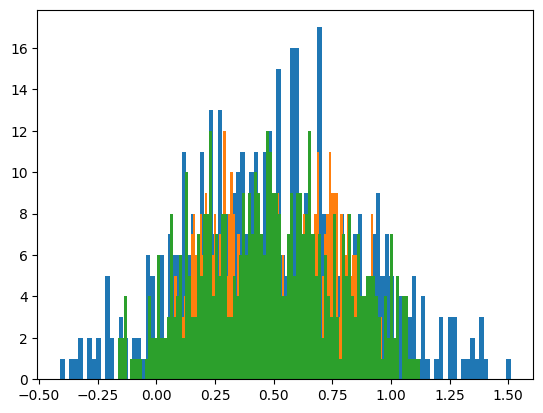

In [41]:
assert source_image.shape == target_image.shape
h, w, c = source_image.shape
source_image_flat = source_image.reshape(h * w, c)
target_image_flat = target_image.reshape(h * w, c)

n_samples = 500

idxs = np.random.choice(source_image_flat.shape[0], n_samples, replace=False)
source_samples = source_image_flat[idxs]
target_samples = target_image_flat[idxs]
plt.hist(target_samples[:, 0], bins=100)
plt.hist(target_samples[:, 1], bins=100)
plt.hist(target_samples[:, 2], bins=100)

In [42]:
result_matrix, degs = regression_matrix(
    source_samples,
    target_samples,
    expected_rot_deg * np.pi / 180.0
)
print(result_matrix)
print(np.linalg.inv(result_matrix))

Trial 0: loss=1.778554564176214, degrees=[ 1.68057285 -0.37079253  1.21872189 -1.36728149]
Trial 1: loss=3.7361091175266274, degrees=[ 2.         -2.          0.43119286 -1.4693259 ]
Trial 2: loss=3.068378827845822, degrees=[ 1.3624338  -0.57622198 -0.67718675  1.19214252]
Trial 3: loss=0.43456115940892626, degrees=[-0.6412925   0.66453713  2.          0.89238531]
Trial 4: loss=0.4872576274869825, degrees=[-0.11512892  0.50078238 -0.47771209 -0.07791495]
Trial 5: loss=4.242227865852126, degrees=[ 1.17668377 -1.72364079  0.44092594 -1.71752378]
Trial 6: loss=5.592831104726109, degrees=[-2.         -1.91201652  1.07574658  0.10618743]
Trial 7: loss=1.1523164105830446, degrees=[-0.25696939  1.11653961 -2.          0.48810083]
Trial 8: loss=0.7930984914664153, degrees=[-0.52651635  0.40970668 -1.08340929 -0.85640032]
Trial 9: loss=0.6989365787567756, degrees=[-0.98542406  0.00641843  1.62005381  1.67336184]
Trial 10: loss=1.069556548081929, degrees=[-0.6226488   1.1433564  -1.95732859 -1.9

In [43]:
print(degs)

[-0.11538099  0.50000154  0.42006877  0.12847492]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6346681..1.6346681].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6053561..1.6053562].


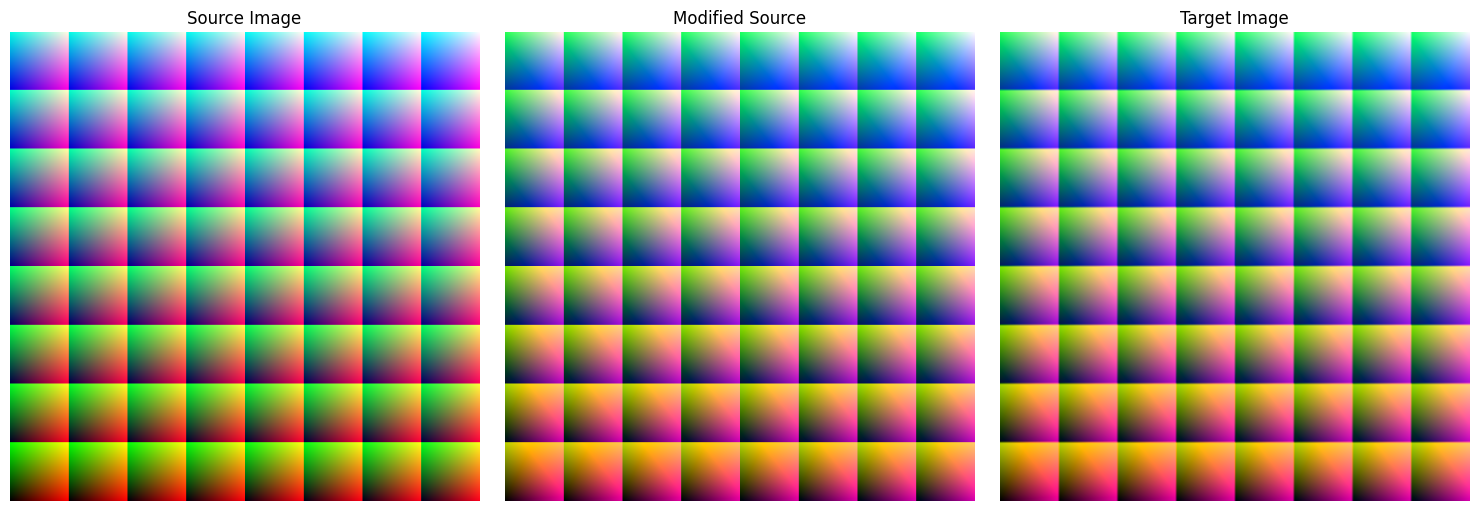

In [44]:
modified_source = forward_bulk(degs, source_image_flat, expected_rot_deg * np.pi / 180.0)
modified_source = modified_source.reshape(h, w, c)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(source_image)
axes[0].set_title("Source Image")
axes[1].imshow(modified_source)
axes[1].set_title("Modified Source")
axes[2].imshow(target_image)
axes[2].set_title("Target Image")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

In [45]:
print(np.mean((modified_source - target_image)**2))

0.0015376097
